In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'D:\House-Price-Prediction\AmesHousing.csv')

In [3]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.shape

(2930, 82)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [6]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [7]:
columns_none_cat = [
    'Fireplace Qu', 'Garage Type', 'Garage Finish',
    'Garage Qual', 'Garage Cond',
    'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
    'BsmtFin Type 1', 'BsmtFin Type 2'
]

for col in columns_none_cat:
    if col in df.columns:
        if 'Fireplace' in col:
            df[col] = df[col].fillna('No Fireplace')
        elif 'Garage' in col:
            df[col] = df[col].fillna('No Garage')
        elif 'Bsmt' in col:
            df[col] = df[col].fillna('No Basement')

columns_zero_num = [
    'Mas Vnr Area', 'Bsmt Full Bath', 'Bsmt Half Bath',
    'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
    'Total Bsmt SF', 'Garage Cars', 'Garage Area',
    'Garage Yr Blt'
]

for col in columns_zero_num:
    if col in df.columns:
        df[col] = df[col].fillna(0)

if 'Lot Frontage' in df.columns:
    df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

df.isnull().sum().sum()

np.int64(12606)

In [8]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = le.fit_transform(X[col])

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

np.sqrt(mean_squared_error(y_test, lr_pred)), r2_score(y_test, lr_pred)

(np.float64(33295.361211457785), 0.8617306578326958)

In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

np.sqrt(mean_squared_error(y_test, rf_pred)), r2_score(y_test, rf_pred)

(np.float64(26653.739160370253), 0.9113916352791146)

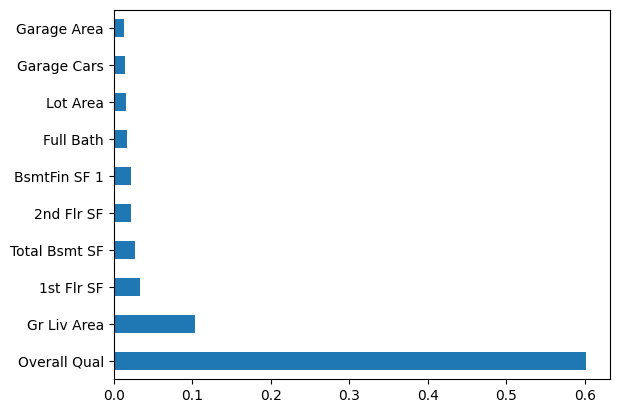

In [15]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

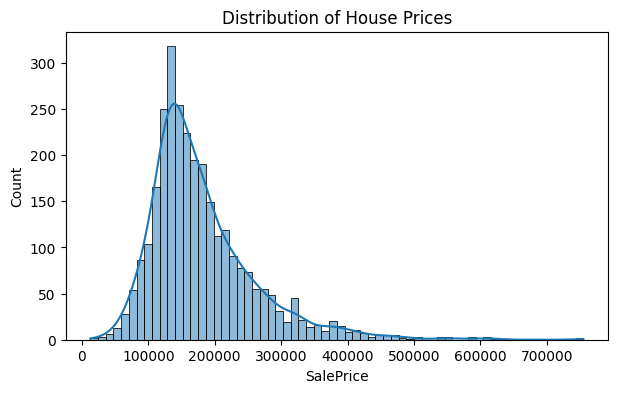

In [16]:
plt.figure(figsize=(7,4))
sns.histplot(df['SalePrice'], kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('SalePrice')
plt.ylabel('Count')
plt.show()

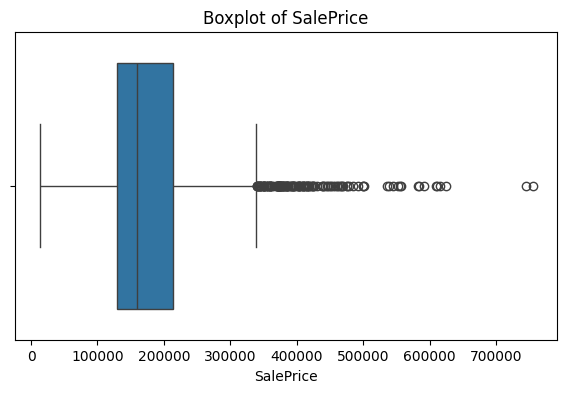

In [17]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['SalePrice'])
plt.title('Boxplot of SalePrice')
plt.show()

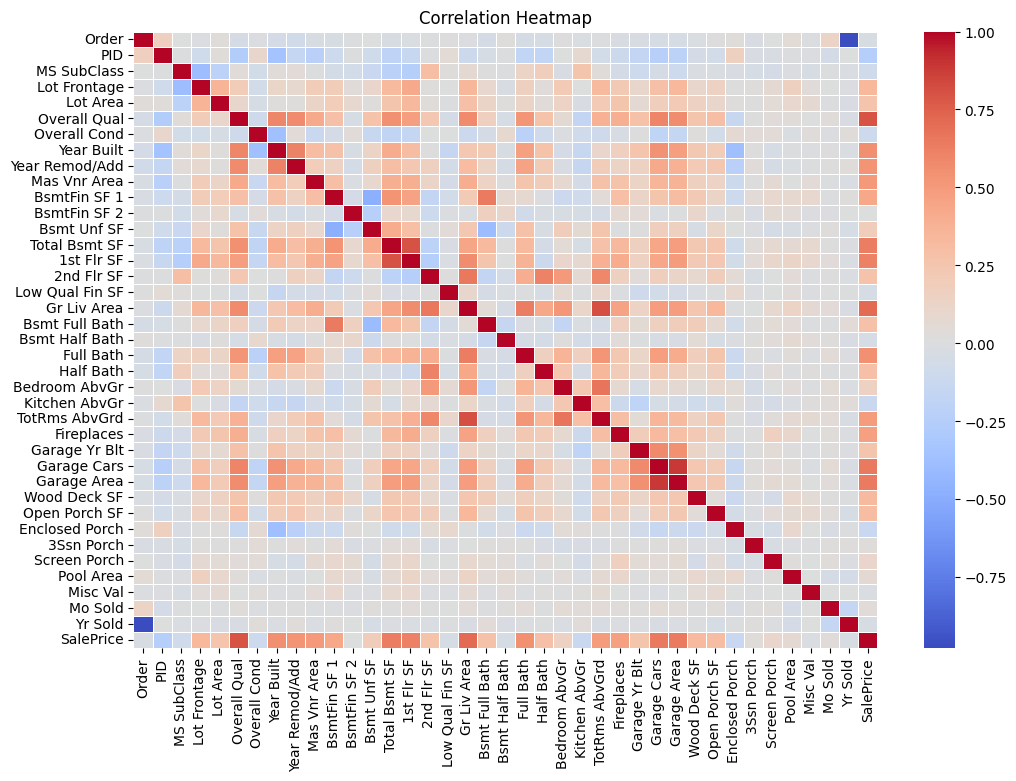

In [18]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

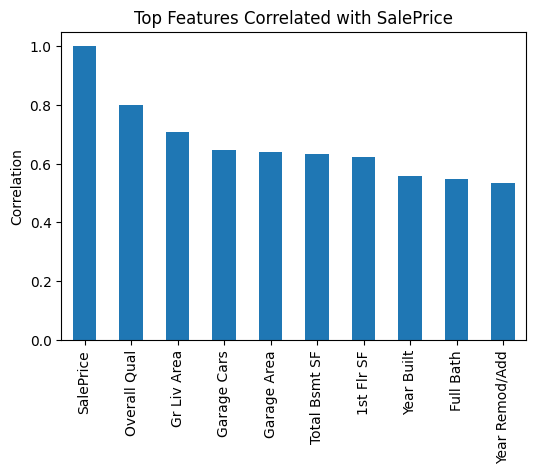

In [19]:
corr_target = corr['SalePrice'].sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
corr_target.plot(kind='bar')
plt.title('Top Features Correlated with SalePrice')
plt.ylabel('Correlation')
plt.show()

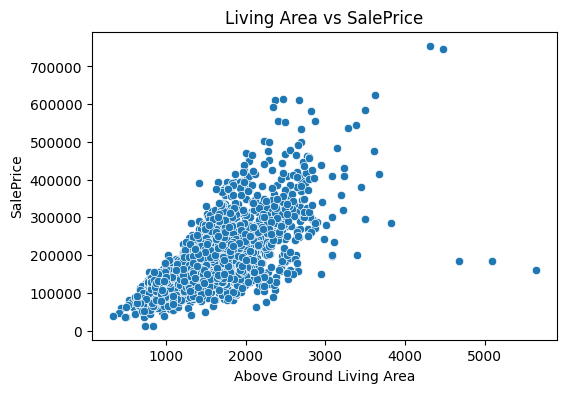

In [20]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['Gr Liv Area'], y=df['SalePrice'])
plt.title('Living Area vs SalePrice')
plt.xlabel('Above Ground Living Area')
plt.ylabel('SalePrice')
plt.show()

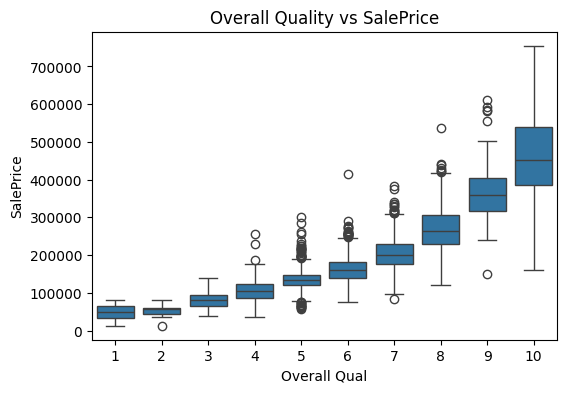

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Overall Qual'], y=df['SalePrice'])
plt.title('Overall Quality vs SalePrice')
plt.show()

In [22]:
from sklearn.model_selection import cross_val_score

cv_rmse = np.sqrt(
    -cross_val_score(
        rf, X, y,
        scoring='neg_mean_squared_error',
        cv=5
    )
)

cv_rmse.mean()

np.float64(26388.68743799806)

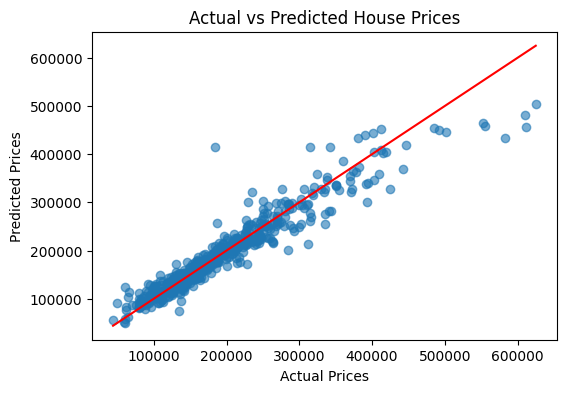

In [23]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()